In [1]:
from dataclasses import dataclass
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np 
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from torchfuzzy import FuzzyLayer, DefuzzyLinearLayer, FuzzyBellLayer, DefuzzyMaxLayer
import piqa
import sklearn.metrics as metrics
from sklearn.manifold import TSNE
from torchvision.transforms import v2
from torchinfo import summary
from matplotlib.colors import ListedColormap


In [2]:
batch_size = 256
learning_rate_ae = 1e-4
num_epochs_ae = 100
latent_dim = 16
kernels = 8
fuzzy_rules_count = 64
mnist_class_anomaly = 4
active_terms = 2
prefix = f"fuzzy_snn"
writer = SummaryWriter(f'runs/mnist/{prefix}_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ssim = piqa.SSIM(window_size = 11, n_channels=1, reduction='none').to(device)
binary_cmap = ListedColormap(['yellow', 'red'], N=2)
device

device(type='cuda')

## Датасет  

In [3]:
def norm_and_transform(x):
    nimg = x.view(-1, 28, 28)
    nimg = torch.clamp(nimg, 0, 1)
    return nimg

def clamp(x):
    #nimg = 2.0*(x.view(-1, 28, 28) - 0.5)
    nimg = torch.clamp(x, 0, 1)
    return nimg

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Lambda(norm_and_transform)
])

augmentation = transforms.Compose([
    transforms.RandomRotation(15, fill=0), 
    transforms.RandomAffine(degrees=5, translate=(0.1, 0.1), fill=0), 
    #transforms.RandomCrop(size=26),
    #transforms.Resize(size=(28, 28)),
    transforms.Lambda(clamp)
])

In [4]:
def get_target_and_mask(target_label):
    t = target_label
    return t 

train_data = datasets.MNIST(
    '~/.pytorch/MNIST_data/', 
    download=True, 
    train=True, 
    transform = transform,
    target_transform = transforms.Lambda(lambda x: get_target_and_mask(x))
)

idx = (train_data.targets != mnist_class_anomaly)
train_data.targets = train_data.targets[idx]
train_data.data = train_data.data[idx]
len(train_data)

54158

загружаем тестовую выборку

In [5]:
test_data = datasets.MNIST(
    '~/.pytorch/MNIST_data/', 
    download=True, 
    train=False, 
    transform=transform, 
    target_transform = transforms.Lambda(lambda x: get_target_and_mask(x))
)
len(test_data)

10000

Создаем итераторы датасетов

In [6]:

train_loader = torch.utils.data.DataLoader(
    train_data, 
    batch_size=batch_size, 
    shuffle=True,
    
)
test_loader = torch.utils.data.DataLoader(
    test_data, 
    batch_size=batch_size, 
    shuffle=False,
)

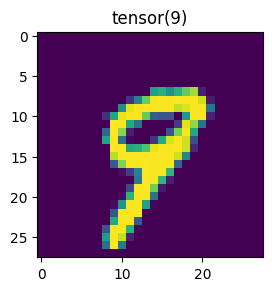

In [7]:
for img, lab in iter(train_loader):
    R, C = 1, 2
    #plt.title(lab[0])
    plt.subplot(R, C, 1)
    plt.title(lab[0])
    plt.imshow(img[0].squeeze())
    break

## Модель

In [8]:
class FSNN(nn.Module):

    def __init__(self, latent_dim, fuzzy_rules_count, decoder_input_size, kernels):
        super(FSNN, self).__init__()
                
        self.encoder = nn.Sequential(
            nn.Conv2d(1, kernels, kernel_size = 5, bias=False), 
            nn.Conv2d(kernels, kernels, kernel_size = 5, bias=False), 
            nn.BatchNorm2d(kernels, affine=False), 
            nn.SiLU(),

            nn.Conv2d(kernels, 2*kernels, kernel_size = 5, bias=False), 
            nn.Conv2d(2*kernels, 2*kernels, kernel_size = 5, bias=False), 
            nn.BatchNorm2d(2*kernels, affine=False), 
            nn.SiLU(),

            nn.Conv2d(2*kernels, 4*kernels, kernel_size = 5, bias=False), 
            nn.Conv2d(4*kernels, 4*kernels, kernel_size = 5, bias=False), 
            nn.BatchNorm2d(4*kernels, affine=False), 
            nn.SiLU(),

            nn.Conv2d(4*kernels, 8*kernels, kernel_size = 4, bias=False), 
            nn.BatchNorm2d(8*kernels, affine=False), 
            nn.Flatten(),
            nn.Linear(8*kernels, latent_dim, bias=False)
        )

        self.decoder = nn.Sequential(
            nn.Linear(fuzzy_rules_count, 8*kernels),
            nn.BatchNorm1d(8*kernels),
            nn.Unflatten(1, (8*kernels, 1, 1)),
            
            nn.ConvTranspose2d(8*kernels, 4*kernels, 4),
            nn.BatchNorm2d(4*kernels),
            nn.SiLU(),

            nn.ConvTranspose2d(4*kernels, 2*kernels, 5),
            nn.ConvTranspose2d(2*kernels, 2*kernels, 5),
            nn.BatchNorm2d(2*kernels),
            nn.SiLU(),

            nn.ConvTranspose2d(2*kernels, kernels, 5),
            nn.ConvTranspose2d(kernels, kernels, 5),
            nn.BatchNorm2d(kernels),
            nn.SiLU(),

            nn.ConvTranspose2d(kernels, kernels, 5),
            nn.ConvTranspose2d(kernels, 1, 5),
            nn.Sigmoid(),
        )

        #main_rad = 1
        exp_k = 1
        sd = fuzzy_rules_count
        
        initial_centroids = []
        initial_scales = []

        #initial_centroids.append(np.repeat(0, latent_dim))
        #initial_scales.append(np.repeat(exp_k, latent_dim))
        for x in np.linspace(0, 2 * np.pi, num = sd, endpoint=False):
            initial_centroids.append([*(2 * exp_k *(0.5 - np.random.random(latent_dim)))])#exp_k * main_rad * np.sin(x), exp_k * main_rad * np.cos(x),
            initial_scales.append([exp_k, exp_k, *np.repeat(exp_k, latent_dim-2)])

        self.fuzzy = FuzzyLayer.from_centers_and_scales(initial_centroids, initial_scales, trainable = True)
        #self.fuzzy = FuzzyLayer.from_dimensions(latent_dim, fuzzy_rules_count) #FuzzyLayer.from_centers_and_scales([np.random.rand(latent_dim)], [np.repeat(1, latent_dim)], trainable = False)
        self.fuzzy_rules_count = fuzzy_rules_count
        #self.defuzzy = DefuzzyMaxLayer.from_dimensions(fuzzy_rules_count, decoder_input_size, trainable=False)#nn.Linear(fuzzy_rules_count, decoder_input_size, bias=False)#
       
        
    def embedding(self, x):
        return self.encoder(x)
    
    def fuzzy_inference(self, dmu):
        fz = self.fuzzy(dmu)
        #dfz = torch.zeros_like(fz)
        #acts = fz.topk(active_terms, -1)
        dfz = fz#torch.scatter(dfz, -1, acts.indices, acts.values)#/ acts.values.sum(-1).unsqueeze(1)
        return fz, dfz
    
    def decode(self, dfz):
        return self.decoder(dfz)
    
    def forward(self, x):
        dmu = self.embedding(x)
        fz, dfz = self.fuzzy_inference(dmu)
        decoded = self.decode(dfz)
        return dmu, fz, dfz, decoded
    
    def set_freeze_fuzzy_except_centroids(self, is_freeze):
        self.fuzzy.scales.requires_grad = not is_freeze
        for r in self.fuzzy.rots:
            r.requires_grad = not is_freeze

#inp = torch.rand(10, 1, 28, 28)
#m = FSNN(latent_dim, fuzzy_rules_count, 16)
#summary(m, input_size=(batch_size, 1, 28, 28))
#fz = torch.rand(3, 4)
#dfz = torch.zeros_like(fz)
#acts = fz.topk(2, -1)
#dfz = torch.scatter(dfz,-1, acts.indices, acts.values / acts.values.sum(-1).unsqueeze(1))


In [9]:
fvae = FSNN(latent_dim=latent_dim, fuzzy_rules_count=fuzzy_rules_count, decoder_input_size=64, kernels=kernels).to(device)

num_params = sum(p.numel() for p in fvae.parameters() if p.requires_grad)
print(f'Number of parameters: {num_params:,}')

summary(fvae, input_size=(batch_size, 1, 28, 28))

Number of parameters: 156,377


Layer (type:depth-idx)                   Output Shape              Param #
FSNN                                     [256, 16]                 --
├─Sequential: 1-1                        [256, 16]                 --
│    └─Conv2d: 2-1                       [256, 8, 24, 24]          200
│    └─Conv2d: 2-2                       [256, 8, 20, 20]          1,600
│    └─BatchNorm2d: 2-3                  [256, 8, 20, 20]          --
│    └─SiLU: 2-4                         [256, 8, 20, 20]          --
│    └─Conv2d: 2-5                       [256, 16, 16, 16]         3,200
│    └─Conv2d: 2-6                       [256, 16, 12, 12]         6,400
│    └─BatchNorm2d: 2-7                  [256, 16, 12, 12]         --
│    └─SiLU: 2-8                         [256, 16, 12, 12]         --
│    └─Conv2d: 2-9                       [256, 32, 8, 8]           12,800
│    └─Conv2d: 2-10                      [256, 32, 4, 4]           25,600
│    └─BatchNorm2d: 2-11                 [256, 32, 4, 4]           

## Losses

In [10]:
def get_activation_loss(fz, active_terms = 1):
    #dfz = torch.zeros_like(fz)
    #acts = fz.topk(active_terms, -1)
    #dfz = torch.scatter(dfz, -1, acts.indices, acts.values)#
    #ndfz = torch.scatter(dfz, -1, acts.indices, acts.values / acts.values.sum(-1).unsqueeze(1)).detach() #
    return (1 - fz.sum(-1)).square() #(ndfz - fz).square().sum(-1) #+ (1 - dfz.sum(-1)).square().sum()

#inp = torch.rand((3,4))
#get_activation_loss(inp)

In [11]:
def centroid_loss(sampled_x, centroids, lambd = 1):
    distances = torch.cdist(sampled_x, centroids)
    neighs = torch.topk(distances, dim=-1, k = fuzzy_rules_count, largest=False).values
    weights = torch.exp(-torch.arange(0, fuzzy_rules_count)/lambd).repeat(sampled_x.shape[0],1).to(device)
    return (weights*neighs).sum(-1)

def centroid_loss_2(sampled_x, centroids, lambd = 1):
    distances = torch.cdist(centroids, sampled_x)
    neighs = torch.topk(distances, dim=-1, k = sampled_x.shape[0], largest=False).values
    weights = torch.exp(-torch.arange(0, sampled_x.shape[0])/lambd).repeat(fuzzy_rules_count,1).to(device)
    return (weights*neighs).sum(-1)

def vanderwaals_loss(centroids, eps = 1, sigma = 1):
    distances = torch.cdist(centroids, centroids)
    add = torch.triu(torch.zeros_like(distances) + sigma/2)
    distances = torch.triu(distances+add).flatten()
    distances = distances[distances.nonzero()].flatten() 
    r = sigma / distances
    U = 4 * eps * (torch.pow(r,12) - torch.pow(r,6))
    return U.mean()

#sigma = 1
#eps = 4
#centroids = fvae.fuzzy.get_centroids()
#vanderwaals_loss(centroids)

# sampled_x = torch.rand(7, latent_dim).to(device)
# distances = torch.cdist(centroids, sampled_x)
# lambd = 2
# neighs = torch.topk(distances, dim=-1, k = sampled_x.shape[0], largest=False).values
# weights = torch.exp(-torch.arange(0, sampled_x.shape[0])/lambd).repeat(fuzzy_rules_count,1).to(device)
# weights*neighs
#neighs = torch.topk(distances, dim=-1, k=fuzzy_rules_count, largest=False).values
#lambd = 2
# weights = torch.exp(-torch.arange(0, fuzzy_rules_count)/lambd).repeat(sampled_x.shape[0],1).to(device)
# weights*neighs

#weights = torch.exp(-torch.arange(0, fuzzy_rules_count)/lambd).repeat(sampled_x.shape[0],1).to(device)
#weights*neighs.values
# (torch.exp(-neighs.indices)*neighs.values).mean()
#deltas = sampled_x.unsqueeze(1).repeat(1, fuzzy_rules_count, 1) - centroids[neighs]
#exponent_part = torch.exp(-neighs/lambd).unsqueeze(2).repeat(1, 1, latent_dim)
#exponent_part*deltas



In [12]:
aimg = torch.rand((2, 1, 28, 28)).to(device)
mu = fvae.embedding(aimg)  
fz, dfz = fvae.fuzzy_inference(mu)
rimg = fvae.decode(dfz)
centroids_loss = centroid_loss(mu, fvae.fuzzy.get_centroids())
reconstruction_loss = (1 - ssim(aimg, rimg))
act = fz.max(-1).values
torch.where(act < 0.1, centroids_loss, reconstruction_loss)
#centroids_loss


tensor([0.9779, 0.9671], device='cuda:0', grad_fn=<WhereBackward0>)

In [13]:
def keep_eigenvals_positive_loss(layer, eps = 1e-10):
    ev = layer.get_transformation_matrix_eigenvals().real.min()
    ev = torch.clamp(ev, max=eps)
    return -ev

def ev_loss(layer, min_vol = 5, max_vol = 15):
    ev = layer.get_transformation_matrix_eigenvals().real
    ev_min = ev.min(-1).values
    ev_max = ev.max(-1).values
    return (ev_min - min_vol).clamp(max = 0).square().sum() + (max_vol - ev_max).clamp(max = 0).square().sum()

In [14]:
def get_match_rates(fz):
    return fz.sum(-1).cpu().numpy()

In [15]:
def get_class_matching_matrix(confm):
    rmat = np.zeros((confm.shape[0], confm.shape[0]))
    winners = np.argmax(confm, axis=0)
    for i in range(confm.shape[1]):
        lm = winners[i]
        rmat[:, lm] += confm[:, i]
    return rmat


## Train

In [16]:
prev_updates = 0

In [17]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']
        
def train(model, dataloader, optimizer, sched, prev_updates, epoch, writer=None):
    model.train()  
    #model.set_freeze_fuzzy_except_centroids(True)
    for batch_idx, (img, _) in enumerate(tqdm(dataloader, disable=True)):
        
        aimg = img.to(device)#augmentation(img).to(device)
        
        optimizer.zero_grad()  
        mu = model.embedding(aimg)  
        fz, dfz = model.fuzzy_inference(mu)
        rimg = model.decode(dfz)
        centroids_loss = centroid_loss_2(mu, model.fuzzy.get_centroids())
        activation_loss = get_activation_loss(fz, active_terms)
        reconstruction_loss = (1 - ssim(aimg, rimg))
        #act = fz.max(-1).values
        #activations_loss = (1 - fz.sum(-1)).square() #(fz - F.one_hot(torch.argmax(fz, -1),fuzzy_rules_count)).square().sum()
        #loss = activations_loss.sum() + centroids_loss.sum() #+  #torch.where(act < 0.2, centroids_loss, reconstruction_loss).sum() # 
        # + activations_loss.sum() +
        #if epoch < 10:
        #    loss =  centroids_loss.sum() + activation_loss.sum() #+ centroids_loss.sum() #+  #torch.where(act < 0.2, centroids_loss, reconstruction_loss).sum() # 
        #else:
        
        loss =  centroids_loss.sum() + reconstruction_loss.sum() + activation_loss.sum() #+ centroids_loss.sum() #+  #torch.where(act < 0.2, centroids_loss, reconstruction_loss).sum() # 
        
        #F.cross_entropy(fz, activations).backward()
        
        loss.backward()
        #(activations_loss + centroids_loss).backward()
        #(nfz.sum() + (1 - fz.max(-1).values).sum()).backward()
        #(1 - fz.max(-1).values).square().sum().backward()
        
        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1e-5)    
        optimizer.step()  

        if sched is not None:
            sched.step()
        
    if writer is not None:
        writer.add_scalar('SVDDF/LR', get_lr(optimizer), global_step=epoch)
        
    return prev_updates + len(dataloader)

In [18]:
def test(model, dataloader, cur_step, epoch, writer=None):
    model.eval() 

    loss_stats = {}
    loss_stats['fz_sum'] = 0.0
    loss_stats['activation_loss'] = 0.0
    
    loss_stats['centroids'] = 0.0
    loss_stats['reconstruction'] = 0.0
    
    embedings = []
    labels_expected = []
    predicted_match = []
    predicted_label = []
    match_true = []
    match_pred = []
    confm = np.zeros((10, fuzzy_rules_count))

    with torch.no_grad():
        for img, la in tqdm(test_loader, desc='Test MNIST', disable=True):
            aimg = img.to(device)
            
            mu = model.embedding(aimg)  
            fz, dfz = model.fuzzy_inference(mu)
            rimg = model.decode(dfz)
            centroids = model.fuzzy.get_centroids()
            loss_stats['centroids'] += centroid_loss_2(mu, centroids).mean().item()
            loss_stats['fz_sum'] +=  (1 - fz.sum(-1)).mean().item()
            loss_stats['reconstruction'] += (1 - ssim(aimg, rimg)).mean().item()
            loss_stats['activation_loss'] += get_activation_loss(fz, active_terms).mean().item()
            #loss_stats['vol_loss'] += ev_loss(model.fuzzy_pos)
            #test_loss += get_loss(fz_a, fz_b, labels) #(fz_a*fz_b).sum(-1).square().mean().item()
            embedings.append(mu.cpu().numpy())
            fz_a_mx = fz.argmax(1)
            predicted_match.append(torch.where(fz.max(1).values > 0.1, fz_a_mx, -1).cpu().numpy())#
            predicted_label.append(la.cpu().numpy())#torch.where(fz_a.max(1).values>0.1, fz_a_mx, -1)
            labels_expected.append((la == mnist_class_anomaly).cpu().numpy())
            
            for i, j in zip(la.cpu().numpy(), fz_a_mx.cpu().numpy()):
                confm[i, j] += 1

            rates = get_match_rates(fz)
            for f, l in  zip(rates, la):
                match_pred.append(f)        
                if l == mnist_class_anomaly:
                    match_true.append(0)
                else:
                    match_true.append(1)
            
    fpr, tpr, _ = metrics.roc_curve(match_true, match_pred)
    roc_auc = metrics.auc(fpr, tpr)

    embedings = np.concatenate(embedings, axis=0)
    predicted_label = np.concatenate(predicted_label, axis = 0)
    predicted_match = np.concatenate(predicted_match, axis = 0)
    labels_expected = np.concatenate(labels_expected, axis = 0)
    print(f'[{cur_step}] {loss_stats}')
    
    if writer is not None:
        writer.add_scalar('SVDDF/AUC', roc_auc, global_step=cur_step)
        for k,v in loss_stats.items():
            writer.add_scalar(f'SVDDF/{k}', v/len(dataloader), global_step=cur_step)
        
        fig, ax = plt.subplots(1, 4, figsize=(16, 4))
        centroids = model.fuzzy.get_centroids().detach().cpu().numpy()
        ax[0].scatter(embedings[:, 0],      embedings[:,  1], c=predicted_label, cmap='tab10', s=2)
        ax[0].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        ax[1].scatter(embedings[:, 0],      embedings[:,  1], c=predicted_match, cmap='tab10', s=2)
        ax[1].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        ax[2].scatter(embedings[:, 0],      embedings[:,  1], c=labels_expected, cmap=binary_cmap, s=2)
        ax[2].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        ax[3].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        
        writer.add_figure('SVDDF/Emedding', fig, global_step=cur_step)

        fig, ax = plt.subplots(1, 1, figsize=(9, 9))
        ax.matshow(get_class_matching_matrix(confm))
        writer.add_figure('SVDDF/ConfMatrix', fig, global_step=cur_step)


        samples = model.decoder(torch.diag(torch.ones(fuzzy_rules_count)).to(device))
        img_idx = 0
        fign, axn = plt.subplots(8, 1 + fuzzy_rules_count//8, figsize=(1 + fuzzy_rules_count//8, 8), squeeze=False)
        for i in range(8):
            if img_idx >= fuzzy_rules_count:
                continue
            for j in range(fuzzy_rules_count//8):
                axn[i, j].imshow(samples[img_idx].view(28, 28).cpu().detach().numpy(), cmap='gray')
                axn[i, j].axis('off')
                img_idx += 1

        writer.add_figure('SVDDF/Samples', fign, global_step=cur_step)



In [19]:
#learning_rate_ae = 1e-6
#num_epochs_ae = 100

In [20]:
optimizer_ae = torch.optim.Adam(list(fvae.encoder.parameters()) + list(fvae.fuzzy.parameters())+ list(fvae.decoder.parameters()) , lr=learning_rate_ae)#
sched = torch.optim.lr_scheduler.ConstantLR( optimizer_ae, learning_rate_ae)
#sched = torch.optim.lr_scheduler.OneCycleLR(optimizer_ae, learning_rate_ae, epochs=num_epochs_ae, steps_per_epoch=len(train_loader))

In [21]:
for epoch in range(num_epochs_ae):    
    prev_updates = train(fvae, train_loader, optimizer_ae, sched, prev_updates, epoch, writer=writer)
    test(fvae, test_loader, prev_updates, epoch, writer=writer)
    #sched_ct.step()
    #scheduler.step()

[212] {'fz_sum': -2.092744253342971, 'activation_loss': 4.277536764740944, 'centroids': 166.8711178302765, 'reconstruction': 21.873830258846283}
[424] {'fz_sum': -4.516981668770313, 'activation_loss': 2.6355025582015514, 'centroids': 156.14263033866882, 'reconstruction': 14.97520437836647}
[636] {'fz_sum': -4.0569720081985, 'activation_loss': 1.8461401760578156, 'centroids': 145.6522023677826, 'reconstruction': 13.181823134422302}
[848] {'fz_sum': -4.786949940025806, 'activation_loss': 1.671619489789009, 'centroids': 133.3292977809906, 'reconstruction': 12.29853281378746}
[1060] {'fz_sum': -3.91390173509717, 'activation_loss': 1.3452105224132538, 'centroids': 124.02664422988892, 'reconstruction': 11.848674148321152}
[1272] {'fz_sum': -4.687072582542896, 'activation_loss': 1.403898837044835, 'centroids': 114.9246666431427, 'reconstruction': 11.487452983856201}
[1484] {'fz_sum': -4.136233739554882, 'activation_loss': 1.1898384056985378, 'centroids': 108.17279195785522, 'reconstruction': 

## Визуализируем результаты

In [22]:
fvae.eval()

FSNN(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (1): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (3): SiLU()
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (5): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (6): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (7): SiLU()
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (9): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (10): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (11): SiLU()
    (12): Conv2d(32, 64, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (14): Flatten(start_dim=1, end_dim=-1)
    (15): Linear(in_fea

In [23]:
fvae.fuzzy.get_transformation_matrix()

tensor([[[ 1.3558,  0.0967, -0.4519,  ..., -0.1774,  0.2131,  0.8069],
         [ 0.0967,  1.2157,  0.0684,  ...,  0.0447,  0.0591,  0.3098],
         [-0.4519,  0.0684,  1.3949,  ...,  0.0973, -0.2935, -0.5920],
         ...,
         [-0.1774,  0.0447,  0.0973,  ...,  1.1933,  0.0550, -1.1351],
         [ 0.2131,  0.0591, -0.2935,  ...,  0.0550,  1.2839,  0.6303],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  1.0000]],

        [[ 1.3077, -0.0141,  0.0272,  ..., -0.0333,  0.0664,  0.1828],
         [-0.0141,  1.1080, -0.0959,  ...,  0.0546, -0.0626, -1.0184],
         [ 0.0272, -0.0959,  1.6254,  ..., -0.2673,  0.0475,  0.9736],
         ...,
         [-0.0333,  0.0546, -0.2673,  ...,  1.1880, -0.0254, -0.9329],
         [ 0.0664, -0.0626,  0.0475,  ..., -0.0254,  1.2706, -0.1524],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  1.0000]],

        [[ 1.0977, -0.0102,  0.0438,  ..., -0.0124, -0.1039, -0.8009],
         [-0.0102,  1.1870,  0.0183,  ..., -0

In [24]:
fvae.fuzzy.get_transformation_matrix_eigenvals().real

tensor([[4.4431, 1.8043, 0.4972,  ..., 0.8993, 0.9572, 0.9428],
        [3.4826, 0.2807, 1.7578,  ..., 0.9308, 0.9470, 0.9806],
        [3.5322, 0.5941, 1.6229,  ..., 1.0039, 0.9387, 0.9650],
        ...,
        [3.7029, 2.7179, 2.1666,  ..., 1.0840, 1.0342, 0.9976],
        [4.1448, 2.5238, 0.3767,  ..., 1.0816, 1.1443, 1.1757],
        [4.1310, 2.5703, 2.5561,  ..., 1.0493, 1.0810, 1.1298]],
       device='cuda:0', grad_fn=<SelectBackward0>)

In [25]:
fvae.fuzzy.get_centroids()

tensor([[-0.1236, -0.1618,  0.0427,  ...,  0.1414,  0.9792, -0.5601],
        [-0.4053,  1.0270,  0.0828,  ..., -0.0144,  1.0373,  0.6034],
        [ 0.8628, -0.5385, -0.3241,  ...,  0.5263, -1.0044, -0.0116],
        ...,
        [ 0.0527, -0.7071, -0.2204,  ...,  0.6891, -0.2844,  0.9534],
        [-0.1654, -0.0603, -0.3032,  ..., -0.1286,  0.9600, -0.4452],
        [ 0.3284,  0.5777,  0.6696,  ..., -0.6147,  0.7146, -0.4976]],
       device='cuda:0', grad_fn=<LinalgSolveExBackward0>)

In [26]:
x = (torch.zeros((10, latent_dim)) + 0).to(device)
fz, nfz = fvae.fuzzy_inference(x)
fz, nfz

(tensor([[0.0504, 0.0375, 0.0603, 0.0392, 0.0515, 0.0505, 0.0665, 0.0546, 0.0388,
          0.0540, 0.0551, 0.0371, 0.0379, 0.0484, 0.0563, 0.0734, 0.0611, 0.0373,
          0.0657, 0.0518, 0.0440, 0.0538, 0.0520, 0.0705, 0.0652, 0.0426, 0.0507,
          0.0604, 0.0515, 0.0502, 0.0640, 0.0541, 0.0457, 0.0686, 0.0705, 0.0534,
          0.0490, 0.0597, 0.0347, 0.0280, 0.0441, 0.0532, 0.0514, 0.0700, 0.0879,
          0.0887, 0.0558, 0.0499, 0.0769, 0.0350, 0.0590, 0.0437, 0.0692, 0.0389,
          0.0866, 0.0467, 0.0569, 0.0603, 0.0420, 0.0604, 0.0646, 0.0406, 0.0619,
          0.0511],
         [0.0504, 0.0375, 0.0603, 0.0392, 0.0515, 0.0505, 0.0665, 0.0546, 0.0388,
          0.0540, 0.0551, 0.0371, 0.0379, 0.0484, 0.0563, 0.0734, 0.0611, 0.0373,
          0.0657, 0.0518, 0.0440, 0.0538, 0.0520, 0.0705, 0.0652, 0.0426, 0.0507,
          0.0604, 0.0515, 0.0502, 0.0640, 0.0541, 0.0457, 0.0686, 0.0705, 0.0534,
          0.0490, 0.0597, 0.0347, 0.0280, 0.0441, 0.0532, 0.0514, 0.0700, 0.087

In [27]:
def get_arate_val(inp):
    _, fz, _, decoded = fvae.forward(inp)  
    return (ssim(inp, decoded)).cpu().numpy()#fz.sum(-1).cpu().numpy()

MNIST HIST:   0%|          | 0/40 [00:00<?, ?it/s]

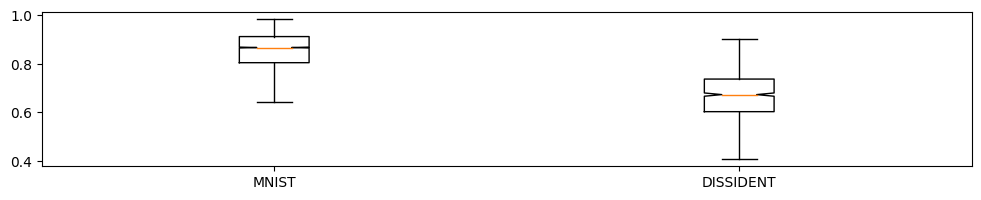

In [28]:
firings_mnist = {}
firings_mnist['MNIST'] = []
firings_mnist['DISSIDENT'] = []

with torch.no_grad():
    for data, target  in tqdm(test_loader, desc='MNIST HIST'):
        data = data.view((-1,1,28,28)).to(device)
        rates = get_arate_val(data)
        for f, l in  zip(rates, target):
            if l != mnist_class_anomaly:
                firings_mnist['MNIST'].append(f)
            else:
                firings_mnist['DISSIDENT'].append(f)
        

labels, data = firings_mnist.keys(), firings_mnist.values()

fig = plt.figure(figsize =(12, 2))
plt.boxplot(data, notch=True, showfliers=False)
plt.xticks(range(1, len(labels) + 1), labels)
plt.show()

writer.add_figure('Anomaly Detection', fig)

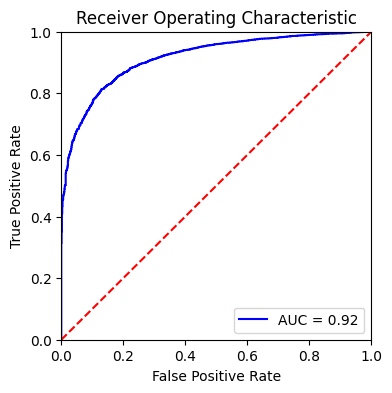

In [29]:
with torch.no_grad():
    firing_levels = []
    lab_true = []
    lab_pred = []

    for data, lab  in tqdm(test_loader, desc='Test MNIST', disable=True):
        data = data.view((-1,1,28,28)).to(device)
        rates = get_arate_val(data)
        
        for f, l in  zip(rates, lab):
            firing_levels.append(f)
            lab_pred.append(f)        
            if l == mnist_class_anomaly:
                lab_true.append(0)
            else:
                lab_true.append(1)
                    
    fpr, tpr, threshold = metrics.roc_curve(lab_true, lab_pred)
    roc_auc = metrics.auc(fpr, tpr)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = threshold[optimal_idx]
    fig = plt.figure(figsize =(4, 4))
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    writer.add_figure('ROC', fig)

In [36]:
optimal_threshold

0.78071135

EMNIST VIS:   0%|          | 0/40 [00:00<?, ?it/s]

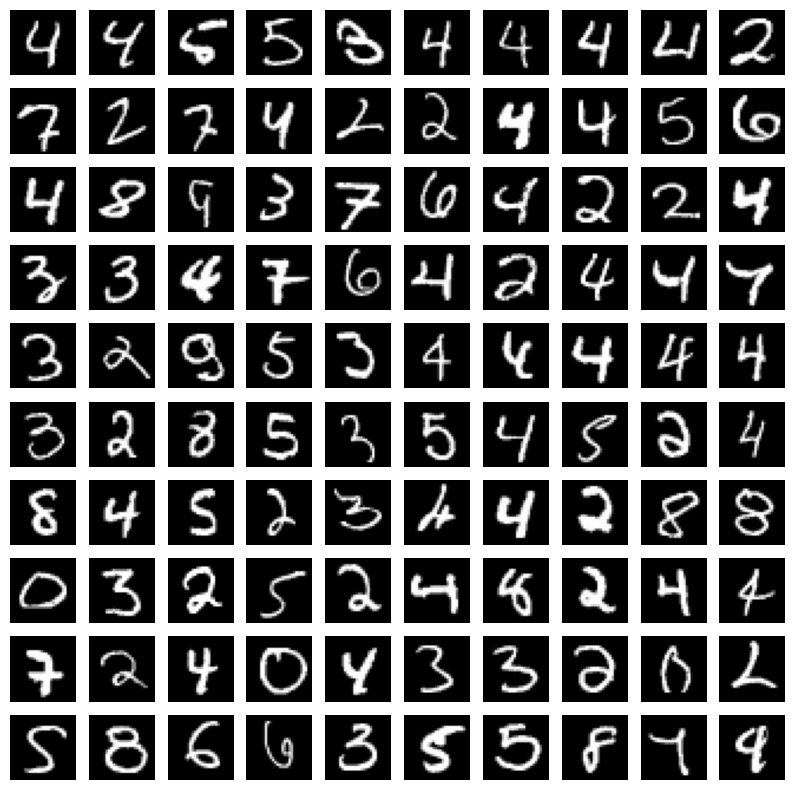

In [ ]:
threshold = optimal_threshold
n = 0
fig, ax = plt.subplots(10, 10, figsize=(10, 10))
with torch.no_grad():
    for data, labels  in tqdm(test_loader, desc='EMNIST VIS'):
        if n >= 100:
            break
        data = data.view((-1, 1, 28, 28)).to(device) 
        
        arate = get_arate_val(data)
        
        for i in range(data.shape[0]):
            if(arate[i] < threshold):
                img = data[i]
                ax[int(n / 10), int(n % 10)].imshow(img.view(28, 28).cpu().detach().numpy(), cmap='gray')
                ax[int(n / 10), int(n % 10)].axis('off')
                n = n + 1
                    
                if n >= 100:
                    break

In [31]:
def show_item_reconstructio(ind):
    for data, trg in iter(test_loader):
        data = data.to(device)
        dmu, fz, dfz, decoded = fvae(data)
        plt.figure(figsize=(24, 6))

        R, C = 1, 6
        np.set_printoptions(precision=1,suppress=True)
        print(f"{trg[ind]} {fz[ind].detach().cpu().numpy()}")
        plt.subplot(R, C, 1)
        plt.imshow(data[ind].cpu().squeeze())
        plt.subplot(R, C, 2)
        plt.imshow(decoded[ind].detach().cpu().squeeze())
        
        plt.subplot(R, C, 3)
        plt.imshow((decoded[ind] - data[ind]).abs().detach().cpu().squeeze())
        break

4 [0.  0.  0.  0.1 0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
0 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.2 0.  0.  0.  0.  0.  0.  0. ]


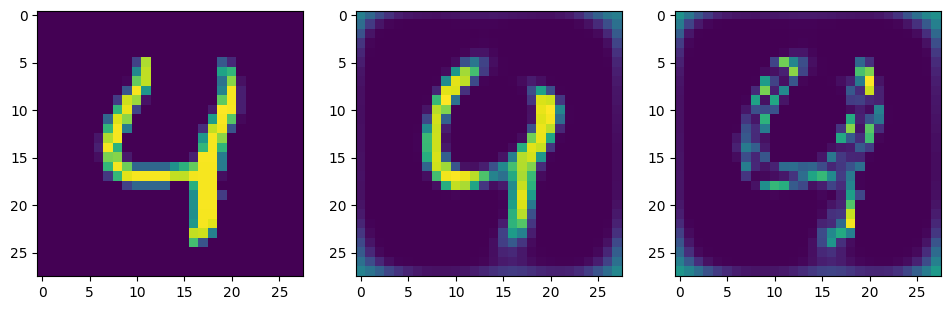

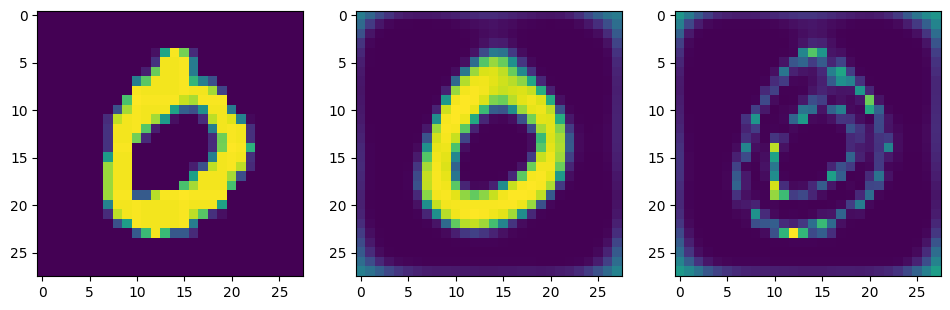

In [32]:
show_item_reconstructio(4)
show_item_reconstructio(3)

In [33]:
embedings = []
labels_expected = []
with torch.no_grad():
    for img, la in tqdm(test_loader, desc='Test MNIST', disable=True):
        aimg = img.to(device)
        mu = fvae.encoder(aimg)  
        fz, dfz = fvae.fuzzy_inference(mu)
        embedings.append(mu.cpu().numpy())
        labels_expected.append((la == mnist_class_anomaly).cpu().numpy())

embedings = np.concatenate(embedings, axis=0)
labels_expected = np.concatenate(labels_expected, axis = 0)
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(embedings)
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
ax.scatter(X_embedded[:, 0],      X_embedded[:,  1], c=labels_expected, cmap=binary_cmap, s=2)
writer.add_figure('SVDDF/TSNE', fig, global_step=num_epochs_ae)

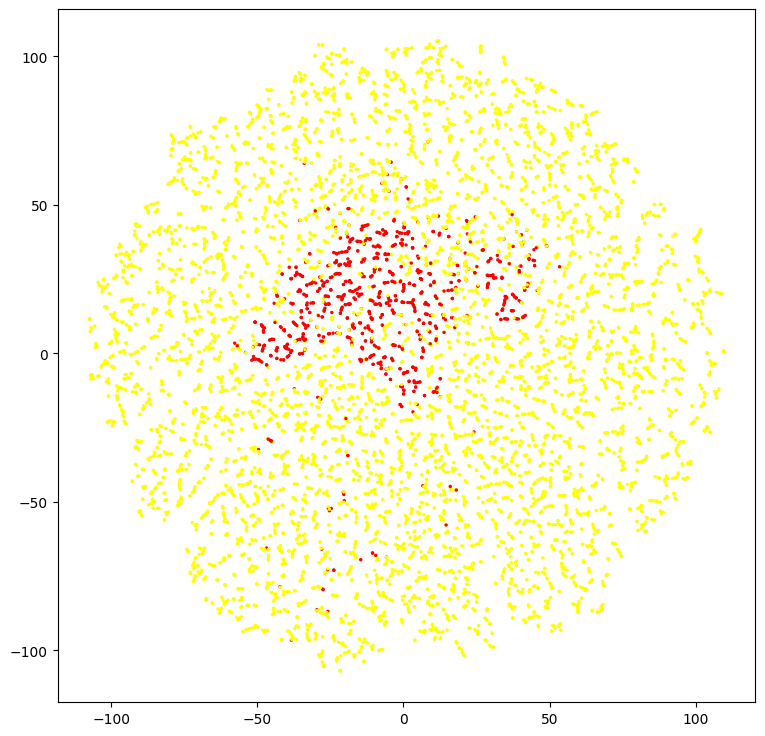

In [34]:
fig